<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/01_binary_plug_and_play_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Plug-and-Play Simulation

## Goal
In this tutorial, you will learn how to run a forward simulation of the binary crowding model. A "forward simulation" means that we already know the protein parameters and the cosolute (crowder) interaction parameters, and we simply want to calculate how the protein's stability changes as a function of the cosolute concentration.

## Setup
We begin by importing the package and `matplotlib.pyplot` for visualization.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

In [2]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np

print(f"Module imported successfully: {cr.__name__}")

Module imported successfully: crowding


## Define the Protein and Cosolute
The model requires:
1. **Protein properties:** Primarily its change in Solvent Accessible Surface Area (SASA) in $A^2$.
2. **Cosolute properties:** The excluded volume parameter ($\nu$), and the Flory-Huggins nonideal interaction parameters ($\chi$ and $\chi_{TS}$).

Let's define a hypothetical small protein and a standard cosolute.

In [3]:
# Define the protein (e.g., SASA = 419.0 A^2)
MET16 = cr.Protein(SASA=419.0)

# Define the cosolute
glycerol = cr.Cosolute(
    nu=2.479,      # Excluded volume parameter
    chi=0.610,     # Flory-Huggins interaction parameter
    chiTS=-3.650   # Entropic component of chi
)

## Build and Solve the Model
Now, we construct the `CrowdingModel`. Since this is a forward simulation, we will arbitrarily set the soft interaction parameters $\varepsilon$ and $\varepsilon_{TS}$ to small non-zero values to see their effect.

We will simulate the concentration range up to $\phi = 0.15$ with a step size of $\Delta \phi=0.0001$.

![Solve Equil Workflow](assets/solve_equil_flowchart.svg)

In [4]:
# Initialize the binary model
model = cr.CrowdingModel(
    protein=MET16,
    cosolute=glycerol,
    eps=-0.05,        # Soft interaction energy
    epsTS=0.01,       # Entropic component of soft interaction
    phiC_max=0.15,    # Maximum volume fraction to simulate
    dphiC=0.0001,      # Step size for the grid
    T=298.15          # Temperature in Kelvin
)

# Solve the thermodynamic equilibrium equations across the concentration grid
model.solve_equil(progress_bar=True)

Solving equilibrium:   0%|          | 0/1499 [00:00<?, ?it/s]

## Extract and Plot Results
The `CrowdingModel` can seamlessly convert all its internal arrays into a `pandas.DataFrame` for easy inspection and plotting.

In [5]:
# Convert results to DataFrame
model.to_pandas()
results = model.results

# Display the first few rows
display(results.head())

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000095,0.9999,0.999905,0.002241,0.002241,0.002241,-0.047195,-2.771956,0.000002,...,1.978132e-09,0.000512,-0.000277,-9.858232e-09,0.00041,0.00041,0.000790,-1.183636e-08,-0.000102,0.000687
1,0.0002,0.000191,0.9998,0.999809,0.004482,0.004483,0.004482,-0.047217,-2.773284,0.000004,...,7.920113e-09,0.001025,-0.000554,-3.947073e-08,0.00082,0.00082,0.001579,-4.739084e-08,-0.000205,0.001374
2,0.0003,0.000286,0.9997,0.999714,0.006723,0.006725,0.006723,-0.047240,-2.774612,0.000006,...,1.783732e-08,0.001537,-0.000831,-8.889421e-08,0.00123,0.00123,0.002369,-1.067315e-07,-0.000307,0.002061
3,0.0004,0.000381,0.9996,0.999619,0.008964,0.008968,0.008963,-0.047263,-2.775940,0.000008,...,3.174116e-08,0.002050,-0.001108,-1.581855e-07,0.00164,0.00164,0.003158,-1.899266e-07,-0.000410,0.002748
4,0.0005,0.000476,0.9995,0.999524,0.011205,0.011211,0.011204,-0.047285,-2.777268,0.000010,...,4.964302e-08,0.002562,-0.001386,-2.474013e-07,0.00205,0.00205,0.003948,-2.970443e-07,-0.000512,0.003435


### Understanding the Results Table

The `results` DataFrame contains a comprehensive thermodynamic profile of the simulated system at each concentration step. Here is a breakdown of the most important columns:

#### Concentrations and Chemical Potentials
- `phiC`, `phiS`: The bulk volume fractions of the Cosolute and Solvent, respectively.
- `phiCsurf`, `phiSsurf`: The volume fractions of the Cosolute and Solvent *inside the protein domain* (the local concentration).
- `molar`, `molal`, `osm`: The bulk cosolute concentration expressed in molarity (M), molality (mol/kg), and osmolality.
- `gamma`, `gammaC`: The solvation and preferential interaction coefficients.

#### Thermodynamic Components (in $k_B T$)
These columns represent the free energy changes ($\Delta\Delta A^0$ or $\Delta\Delta G^0$), enthalpy changes ($\Delta\Delta E^0$ or $\Delta\Delta H^0$), and entropy changes ($T\Delta\Delta S^0$) broken down by their physical origin:
- `*_nu`: The contribution from **excluded volume** (steric repulsions).
- `*_chi`: The contribution from **Flory-Huggins** non-ideal solvent interactions.
- `*_eps`: The contribution from **soft interactions** between the protein and cosolute.
- `ddA`, `ddE`, `TddS`: The **total** sum of the components for free energy, enthalpy, and entropy.

#### Thermodynamic Components (in kJ/mol)
All the thermodynamic columns listed above are also provided in standard chemical units (kJ/mol), indicated by the `_kJ` suffix (e.g., `ddA_kJ`, `ddA_nu_kJ`, `TddS_kJ`).

## Exporting Results
You can export the results DataFrame to a CSV file for your own records or for plotting in other software (e.g., Origin, Prism).

In [6]:
# Export to CSV (commented out to prevent writing during the tutorial)
# results.to_csv("binary_simulation_results.csv", index=False)
print("Simulation complete! You can now analyze the `results` dataframe.")

Simulation complete! You can now analyze the `results` dataframe.


# Binary Model: Plotting Showcase

This notebook demonstrates the plotting functionality available in the `Plotter` for analyzing and visualizing the thermodynamics of the binary crowding model (protein + solvent + single cosolute).

In [8]:
from cr.plotting import Plotter

plotter = Plotter(model)

ModuleNotFoundError: No module named 'cr'

## Comprehensive Results Plot

The `plot_results()` method generates a 3x3 grid of subplots covering all critical thermodynamic properties.

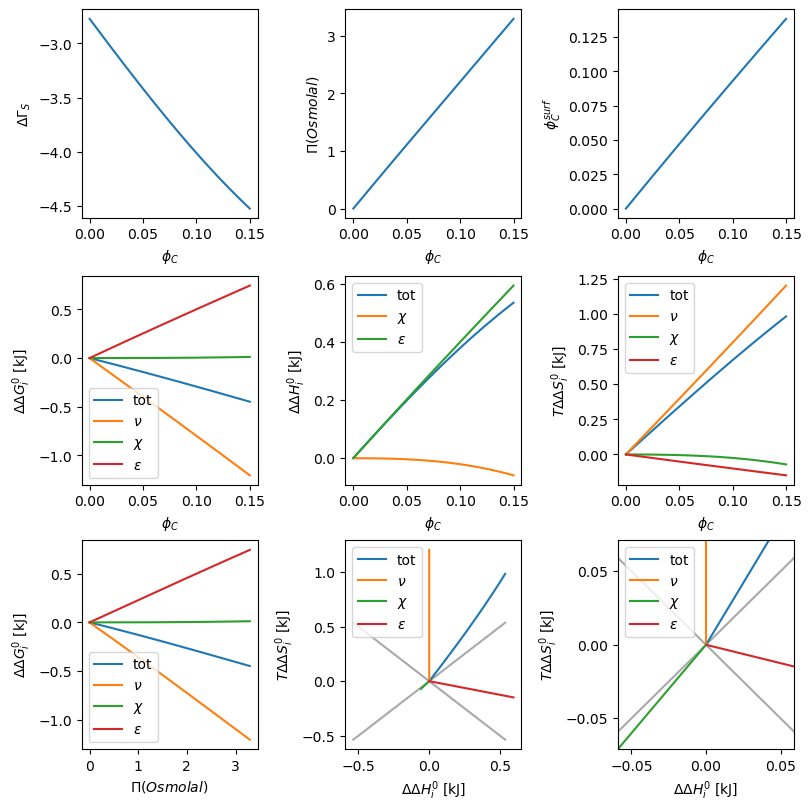

In [8]:
fig = plotter.plot_results()
plt.show()

## Individual Plots

The `Plotter` also provides individual plotting methods. By default, the x-axis is volume fraction ($\phi$), but you can change it using `concentration_type='molal'` or `concentration_type='molar'`.

### Preferential Interaction Parameter ($\Delta\Gamma_S$)

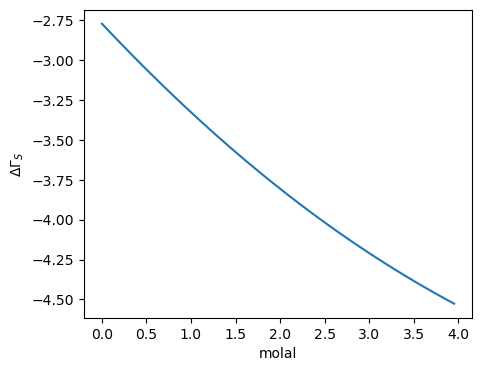

In [9]:
fig = plotter.plot_gamma(concentration_type='molal')
plt.show()

### Folding Free Energy ($\Delta\Delta G^0$)

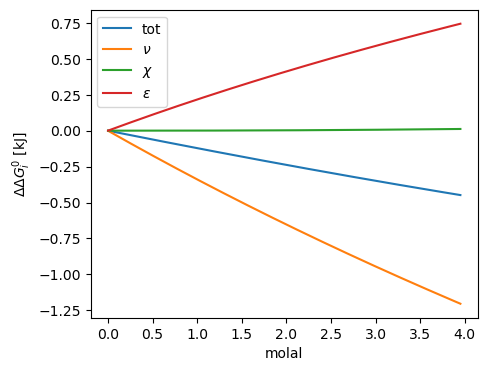

In [10]:
fig = plotter.plot_ddG(concentration_type='molal')
plt.show()

### Folding Enthalpy ($\Delta\Delta H^0$)

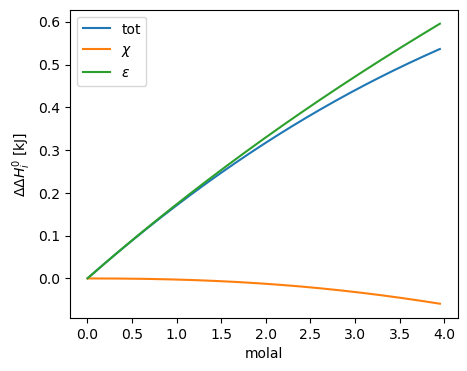

In [11]:
fig = plotter.plot_ddH(concentration_type='molal')
plt.show()

### Folding Entropy ($T\Delta\Delta S^0$)

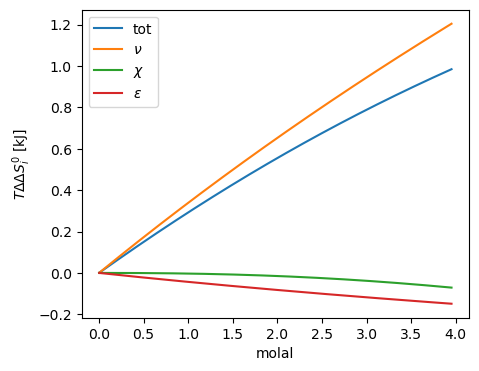

In [12]:
fig = plotter.plot_TddS(concentration_type='molal')
plt.show()

### Chemical Potential ($\mu$)

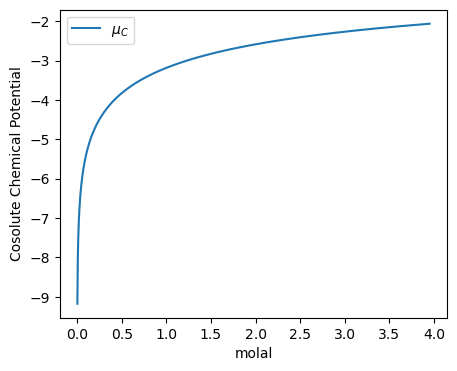

In [13]:
fig = plotter.plot_mu(concentration_type='molal')
plt.show()

### Osmotic Pressure ($\Pi$)

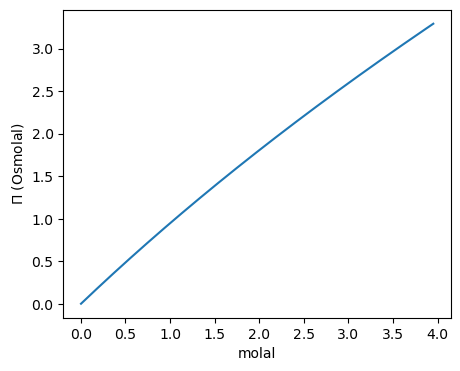

In [14]:
fig = plotter.plot_osm(concentration_type='molal')
plt.show()

### Enthalpy-Entropy Compensation (Standalone)

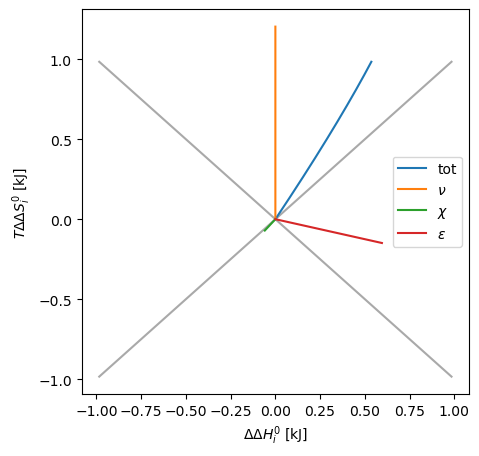

In [15]:
fig = plotter.plot_EEC()
plt.show()